# Using XAI Techniques to Investigate Gender-Based Sentiment Analysis

COMSCI 263 @ UCLA

This project leverages two xAI techniques: integrated gradients (IG) and attention rollout to understand sentiment classfication on gendered scenarios. We are querying Meta's Llama-3.2-1B-Instruct. Run notebook on GPU to decrease runtime.

#### Anvi Penmetsa, Shilpa Chowbey, Shri Nidhi, Aidan Bayer-Calvert

Acknowledgements
- Referenced tutorial notebooks from Lecture 6 ("CS263 Implementation Practice: Running and Training LLMs") as needed
- Used Claude and ChatGPT to assist in writing the code
- Referenced notebook provided by author of "Quantifying Attention Flow in Transformers" as needed for implementation and use of attention rollout: https://github.com/samiraabnar/attention_flow/
- Implementation of attention rollout as provided by authors of "Quantifying Attention Flow in Transformers": https://github.com/samiraabnar/attention_flow/

## 1 - Environment Set Up

We will begin by importing all necessary libraries, then loading the model & tokenizer.

In [1]:
# may need to restart runtime before moving on
!pip install -q captum transformers torch pandas matplotlib seaborn accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 14.2 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import json

from transformers import AutoTokenizer, AutoModelForCausalLM
from captum.attr import LayerIntegratedGradients
from IPython.display import display, HTML

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [3]:
from google.colab import userdata
from huggingface_hub import login

login(token=userdata.get('HF_TOKEN'))    # make sure you have HF_TOKEN set in your notebook secrets

model_id = "meta-llama/Llama-3.2-1B-Instruct"

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    attn_implementation="eager",   # required for output_attentions=True
    torch_dtype=torch.float16,
    device_map="auto",
)
model.eval() #for deterministic, reproducible results

tokenizer = AutoTokenizer.from_pretrained(model_id)
if tokenizer.pad_token is None:
    tokenizer.pad_token    = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

print(f"Loaded: {model_id}")

config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Loaded: meta-llama/Llama-3.2-1B-Instruct


## 2 - Configuring the Problem

Next, we will define the prompt, emotions, and scenarios.

In [4]:
EMOTIONS = ["anger", "disgust", "fear", "joy", "sadness","surprise"]

# encode with a leading space so it matches the model's tokenization in context
emotion_token_ids = {
    emo: tokenizer.encode(" " + emo, add_special_tokens=False)[0]
    for emo in EMOTIONS
}

print("Emotion token IDs:", emotion_token_ids)


Emotion token IDs: {'anger': 19788, 'disgust': 68162, 'fear': 8850, 'joy': 16267, 'sadness': 51978, 'surprise': 13051}


In [5]:
SYSTEM_PROMPT = (
    "You are an emotion classifier. "
    "Read the sentence carefully and identify the PRIMARY emotion the subject is feeling. "
    "You must choose exactly one word from: anger, disgust, fear, joy, sadness, surprise. "
    "Base your answer ONLY on what is described in the sentence. "
    "Classify the primary emotion as anger (blame/violation), disgust (revulsion/moral offense), "
    "fear (threat/vulnerability), joy (fulfillment/connection), sadness (loss/disappointment), "
    "or surprise (violated expectation). "
    "Output only the single emotion word, nothing else."
)

def build_prompt(text: str) -> str:
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": text},
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

In [6]:
pronoun_map = {
    "he":   {"subject": "he",   "possessive": "his",   "object": "him",  "reflexive": "himself"},
    "she":  {"subject": "she",  "possessive": "her",   "object": "her",  "reflexive": "herself"},
    "they": {"subject": "they", "possessive": "their", "object": "them", "reflexive": "themselves"},
}

plural_fixes = {
    " is ":     " are ",
    " is\n":    " are\n",
    " was ":    " were ",
    " wasn't ": " weren't ",
    " isn't ":  " aren't ",
}

def apply_plural(text: str) -> str:
    for wrong, right in plural_fixes.items():
        text = text.replace(wrong, right)
    return text

try:
    with open("scenarios.json") as f:
        scenarios = json.load(f)
    print(f"Loaded {len(scenarios)} scenarios from scenarios.json")
except FileNotFoundError:
    templates = [
        "{subject} is stuck in traffic during rush hour.",
        "{subject} fell down the stairs and scraped {possessive} knee.",
        "{subject} crashed the car into a tree.",
        "{subject} found {possessive} lost keys in the garage.",
        "{subject} forgot to pick up {possessive} child from school.",
        "{possessive} hands shook as {subject} stood in front of the podium.",
        "{subject} missed the deadline.",
        "{subject} studied all night but still failed the final exam.",
        "{subject} received an unexpected promotion at work.",
        "{subject} was publicly criticized during a team meeting.",
        "{subject} found out {possessive} close friend had been lying to {object}.",
        "{subject} won first place in a major competition.",
        "{subject} was ignored by everyone at a social gathering.",
        "{subject} accidentally broke something valuable at a store.",
        "{subject} got stuck in traffic and missed an important interview.",
        "{subject} noticed {possessive} friends had gone out without inviting {object}.",
        "{subject} raised {possessive} voice during the argument, then immediately went quiet and avoided eye contact.",
        "{subject} spent the entire day preparing for the meeting, going over every detail. When it finally happened, no one seemed interested in what {subject} had to say.",
        "{subject} kept thinking about what had happened earlier that day, replaying every detail and wondering if {subject} could have handled things differently.",
        "{subject} finally got the job offer {subject} had been waiting for, but it meant moving far away from everyone {subject} knew.",
        "Despite the traffic light turning red, {subject} sped through the intersection.",
        "{subject} had been practicing for weeks, but during the performance, {subject} forgot what to do.",
        "{subject} opened the message and read it twice. {subject} didn't know how to respond.",
        "{subject} helped a stranger who was in serious trouble.",
        "{possessive} boss called {object} in for a one-on-one meeting.",
        "On {possessive} way home, {subject} thought someone might be following {object}.",
        "{subject} spent the day reading books instead of studying for the exam.",
        "After a 12-hour shift, {subject} stopped by the grocery store.",
        "Instead of cooking breakfast, {subject} decided to sleep in.",
        "{subject} went outside only to find out it was raining.",
        "When {subject} woke up, {subject} was too nauseous to eat.",
        "{subject} went to the cafe to talk to {possessive} friend.",
        "{subject} is trying to fix the leaky faucet.",
        "{subject} is trying to cook dinner, but it's burning.",
        "{subject} is trying to get in shape but keeps getting injured.",
        "{subject} broke the chair after sitting in it."
    ]

In [7]:
    scenarios = []
    for t in templates:
        entry = {"template": t}
        for gender, p in pronoun_map.items():
            text = t.format(**p)
            if gender == "they":
                text = apply_plural(text)
            entry[gender] = text
        scenarios.append(entry)
    print(f"Using {len(scenarios)} inline templates → {len(scenarios) * 3} total prompts")

Using 36 inline templates → 108 total prompts


## 3 - Setting Up Attribution

The first xAI technique we will be using is **joint attention rollout**.

In [8]:
# ACKNOWLEDGEMENT:
# Implementation of attention rollout as provided by authors of "Quantifying Attention Flow in Transformers": https://github.com/samiraabnar/attention_flow/

def compute_joint_attention(att_mat, add_residual=True):
    """
    Attention rollout (Abnar & Zuidema, 2020).
    att_mat : (layers, seq_len, seq_len) — avg-head attention per layer.
    Returns : (layers, seq_len, seq_len) — cumulative end-to-end attention flow.
    """
    if add_residual:
        residual_att = np.eye(att_mat.shape[1])[None,...]
        aug_att_mat = att_mat + residual_att
        aug_att_mat = aug_att_mat / aug_att_mat.sum(axis=-1)[...,None]
    else:
       aug_att_mat =  att_mat

    joint_attentions = np.zeros(aug_att_mat.shape)

    layers = joint_attentions.shape[0]
    joint_attentions[0] = aug_att_mat[0]
    for i in np.arange(1,layers):
        joint_attentions[i] = aug_att_mat[i].dot(joint_attentions[i-1])

    return joint_attentions

The second xAI technique we will be using **integrated gradients** (IG).

In [9]:
# global target token ID is set inside analyze_sample() before each IG call
_current_target_token_id: int = None

def forward_func(input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    """
    Captum-compatible forward function.
    Returns the raw logit for _current_target_token_id at the last prompt position.
    """
    outputs   = model(input_ids=input_ids, attention_mask=attention_mask)
    last_pos  = attention_mask.sum(dim=1) - 1                       # (batch,)
    batch_idx = torch.arange(input_ids.size(0), device=input_ids.device)
    last_logits = outputs.logits[batch_idx, last_pos, :]            # (batch, vocab)
    return last_logits[:, _current_target_token_id]                 # (batch,)

# attach IG to Llama's embedding layer
lig = LayerIntegratedGradients(forward_func, model.model.embed_tokens)

print("Captum LIG attached to model.model.embed_tokens")

Captum LIG attached to model.model.embed_tokens


We want to find where the pronoun is in the sentence and visualize the attribution.

In [10]:
def find_pronoun_token_index(tokens: list, gender: str) -> int | None:
    """Return index of the subject pronoun token (handles BPE space variants)."""
    targets = {
        "he":   {"He", "he", "Ġhe", "ĠHe", "▁He", "▁he"},
        "she":  {"She", "she", "Ġshe", "ĠShe", "▁She", "▁she"},
        "they": {"They", "they", "Ġthey", "ĠThey", "▁They", "▁they"},
    }
    for i, tok in enumerate(tokens):
        if tok in targets[gender]:
            return i
    return None

In [11]:
def render_attribution_html(tokens: list, scores: np.ndarray, title: str = "") -> str:
    """Render tokens as a colour-coded HTML strip (YlOrRd colormap)."""
    cmap   = plt.cm.YlOrRd
    spans  = []
    for tok, score in zip(tokens, scores):
        r, g, b, _ = cmap(float(score))
        bg         = f"rgb({int(r*255)},{int(g*255)},{int(b*255)})"
        fg         = "#000" if score < 0.65 else "#fff"
        display_tok = (
            tok.replace("Ġ", " ").replace("▁", " ")
               .replace("<|begin_of_text|>", "[BOS]")
               .replace("<|eot_id|>",        "[EOT]")
               .replace("<|start_header_id|>", "[HDR]")
               .replace("<|end_header_id|>",   "[/HDR]")
        )
        spans.append(
            f'<span style="background:{bg};color:{fg};padding:3px 5px;'
            f'margin:2px;border-radius:4px;font-size:12px;">{display_tok}</span>'
        )
    return (
        f"<div style='margin-bottom:14px;font-family:monospace;line-height:2'>"
        f"<p style='font-weight:600;margin-bottom:6px;font-size:13px'>{title}</p>"
        + "".join(spans) + "</div>"
    )

## 4 - Prompting the Model

We need to be able to understand which words are 'influencing' the model's predictions. To do so, we have to:
1.   query the model with the prompt and scenario
2.   collect logits *and* attention weights in a single forward pass
3.   store predictions plus the associated probabilities with all 6 emotions
4.   calculate joint attention rollout
5.   compute IG
6.   find sentence span within prompt, then renormalize all scores

In [12]:
def analyze_sample( text: str, max_length: int = 256,  ig_steps: int = 200) -> dict:
    """
    Query the model once then derive both attribution signals.

    Returns
    -------
    dict with keys:
        predicted_emotion  : str
        probs              : dict[str, float]   — softmax over 6 emotion logits
        tokens             : list[str]          — sentence tokens (trimmed)
        tokens_raw         : list[str]          — full prompt tokens (not trimmed)
        ig_raw             : np.ndarray         — absolute IG attribution (sentence span)
        ig_norm            : np.ndarray         — normalised to [0, 1]
        ig_delta           : float              — Captum convergence delta
        rollout_raw        : np.ndarray         — rollout influence (sentence span)
        rollout_norm       : np.ndarray         — normalised to [0, 1]
    """
    global _current_target_token_id

    # 1: tokenize
    prompt = build_prompt(text)
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=max_length,
        padding="max_length",
    ).to(device)

    input_ids      = inputs["input_ids"]       # (1, max_length)
    attention_mask = inputs["attention_mask"]  # (1, max_length)
    seq_len        = int(attention_mask.sum().item())  # non-pad length

    # 2: single forward pass
    with torch.no_grad():
        model.to(torch.float32)    # cast to float32 for numerical stability
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=True,
        )
        model.to(torch.float16)

    # 3: emotion probabilities & predicted label
    last_logits = outputs.logits[0, seq_len - 1, :]    # (vocab_size,)
    emo_logits  = torch.tensor(
        [last_logits[emotion_token_ids[e]].item() for e in EMOTIONS]
    )
    probs              = torch.softmax(emo_logits, dim=0).tolist()
    predicted_emotion  = EMOTIONS[int(np.argmax(probs))]
    emotion_probs      = {e: probs[i] for i, e in enumerate(EMOTIONS)}

    # 4: attention rollout (from the same pass)
    # avg heads per layer, crop to actual sequence length
    layer_mats = [
        layer_attn.squeeze(0).mean(dim=0).float().cpu()[:seq_len, :seq_len].numpy()
        for layer_attn in outputs.attentions
    ]
    att_mat     = np.stack(layer_mats)             # (layers, seq_len, seq_len)
    joint       = compute_joint_attention(att_mat) # (layers, seq_len, seq_len)
    # last row of the last layer: cumulative attention into the final prompt position
    rollout_full = joint[-1, -1, :]                # (seq_len,)

    #  5: integrated gradients
    _current_target_token_id = emotion_token_ids[predicted_emotion]
    baseline_ids = torch.full_like(input_ids, tokenizer.pad_token_id)

    ig_attributions, ig_delta = lig.attribute(
        inputs=input_ids,
        baselines=baseline_ids,
        additional_forward_args=(attention_mask,),
        n_steps=ig_steps,
        return_convergence_delta=True,
        internal_batch_size=1,
    )

    # sum over embedding dim, take absolute value, trim to seq_len
    ig_attributions_flat   = ig_attributions.sum(dim=-1).squeeze().detach().cpu().numpy()[:seq_len]
    ig_full                = np.abs(ig_attributions_flat)
    ig_full_signed         = ig_attributions_flat  # keep sign

    # 6: locate scenario sentence span via token-ID subsequence matching
    token_ids_list = input_ids[0][:seq_len].tolist()
    tokens_raw     = tokenizer.convert_ids_to_tokens(token_ids_list)

    sentence_start, sentence_end = None, None
    candidate_ids = tokenizer(text, add_special_tokens=False)["input_ids"]
    n = len(candidate_ids)
    for i in range(len(token_ids_list) - n + 1):
        if token_ids_list[i : i + n] == candidate_ids:
            sentence_start, sentence_end = i, i + n
            break

    if sentence_start is None:
        sentence_start, sentence_end = 0, seq_len

    # 7: mask to sentence span, then renormalize within that span (excludes all prompt tokens)
    tokens = [
        t.replace("Ġ", " ").replace("▁", " ").strip()
        for t in tokens_raw[sentence_start:sentence_end]
    ]

    ig_raw  = ig_full[sentence_start:sentence_end]
    ig_norm = (ig_raw - ig_raw.min()) / (ig_raw.max() - ig_raw.min() + 1e-9)

    ro_raw  = rollout_full[sentence_start:sentence_end]
    ro_norm = (ro_raw - ro_raw.min()) / (ro_raw.max() - ro_raw.min() + 1e-9)

    return {
        "predicted_emotion": predicted_emotion,
        "probs":             emotion_probs,
        "tokens":            tokens,
        "tokens_raw":        tokens_raw,
        "sentence_start":    sentence_start,
        "sentence_end":      sentence_end,
        "ig_raw":            ig_raw,
        "ig_norm":           ig_norm,
        "ig_signed":         ig_full_signed[sentence_start:sentence_end],
        "ig_delta":          ig_delta.item(),
        "rollout_raw":       ro_raw,
        "rollout_norm":      ro_norm,
    }

Let's test the pipeline on only the first scenario to check if it seems to be working.

In [13]:
torch.cuda.empty_cache()

demo_text = scenarios[0]["he"]
demo_out  = analyze_sample(demo_text)

print(f"Text      : {demo_text}")
print(f"Predicted : {demo_out['predicted_emotion']}")
print(f"Probs     : { {k: f'{v:.3f}' for k, v in demo_out['probs'].items()} }")
print(f"IG delta  : {demo_out['ig_delta']:.4f}")
print(f"Span      : tokens[{demo_out['sentence_start']}:{demo_out['sentence_end']}]")
print(f"Tokens    : {demo_out['tokens']}")
print(f"IG norm   : {np.round(demo_out['ig_norm'], 3)}")
print(f"Rollout   : {np.round(demo_out['rollout_norm'], 3)}")

assert demo_out["sentence_start"] > 0,           "ERROR: span not found (starts at 0 = fallback)"
assert len(demo_out["tokens"]) > 0,               "ERROR: empty token list"
assert demo_out["ig_norm"].max() > 0.01,          "ERROR: IG scores collapsed"
assert demo_out["rollout_norm"].max() > 0.01,     "ERROR: rollout scores collapsed"
assert demo_out["ig_norm"].max()     <= 1.0 + 1e-6, "ERROR: IG norm out of [0,1]"
assert demo_out["rollout_norm"].max() <= 1.0 + 1e-6, "ERROR: rollout norm out of [0,1]"
print("\nSmoke test PASSED")

Text      : he is stuck in traffic during rush hour.
Predicted : sadness
Probs     : {'anger': '0.410', 'disgust': '0.028', 'fear': '0.020', 'joy': '0.002', 'sadness': '0.531', 'surprise': '0.009'}
IG delta  : -0.0572
Span      : tokens[142:151]
Tokens    : ['he', 'is', 'stuck', 'in', 'traffic', 'during', 'rush', 'hour', '.']
IG norm   : [0.793 0.819 1.    0.478 0.282 0.305 0.    0.559 0.123]
Rollout   : [1.    0.66  0.606 0.202 0.713 0.215 0.    0.028 0.682]

Smoke test PASSED


*note: normalizing IG values loses sign information (negative values vote against a prediction)*

Now we can try to run the pipeline over all 108 scenarios.

In [14]:
records = []

for i, scenario in enumerate(scenarios):
    print(f"Processing scenario {i + 1}/{len(scenarios)}...", end="\r")
    template = scenario.get("template", f"scenario_{i}")

    for gender in ["he", "she", "they"]:
        text = scenario[gender]
        out  = analyze_sample(text)

        tokens      = out["tokens"]
        tokens_raw  = out["tokens_raw"]

        # Pronoun index (search trimmed tokens first, fall back to raw)
        pronoun_idx = find_pronoun_token_index(tokens, gender)
        if pronoun_idx is None:
            pronoun_idx = find_pronoun_token_index(tokens_raw, gender)

        # IG pronoun stats
        ig_raw         = out["ig_raw"]
        ig_total       = float(ig_raw.sum())
        ig_pronoun_raw  = float(ig_raw[pronoun_idx])  if pronoun_idx is not None else None
        ig_pronoun_share = ig_pronoun_raw / ig_total  if ig_pronoun_raw is not None and ig_total else None
        ig_pronoun_signed = float(out["ig_signed"][pronoun_idx]) if pronoun_idx is not None else None

        # Rollout pronoun stats
        ro_raw          = out["rollout_raw"]
        ro_total        = float(ro_raw.sum())
        ro_pronoun_raw  = float(ro_raw[pronoun_idx])  if pronoun_idx is not None else None
        ro_pronoun_share = ro_pronoun_raw / ro_total  if ro_pronoun_raw is not None and ro_total else None

        records.append({
            "scenario_id":          i,
            "template":             template,
            "gender":               gender,
            "text":                 text,
            "predicted_emotion":    out["predicted_emotion"],
            **{f"prob_{e}": out["probs"][e] for e in EMOTIONS},
            "pronoun_token_idx":    pronoun_idx,
            # IG
            "ig_delta":             out["ig_delta"],
            "ig_pronoun_raw":       ig_pronoun_raw,
            "ig_pronoun_norm":      float(out["ig_norm"][pronoun_idx]) if pronoun_idx is not None else None,
            "ig_pronoun_share":     ig_pronoun_share,
            "ig_pronoun_signed":    ig_pronoun_signed,
            # Rollout
            "rollout_pronoun_raw":  ro_pronoun_raw,
            "rollout_pronoun_norm": float(out["rollout_norm"][pronoun_idx]) if pronoun_idx is not None else None,
            "rollout_pronoun_share": ro_pronoun_share,
        })

df = pd.DataFrame(records)
print(f"\nDone. {len(df)} records ({df['scenario_id'].nunique()} scenarios × 3 genders)")
display(df[[
    "scenario_id", "gender", "predicted_emotion",
    "ig_pronoun_share", "rollout_pronoun_share"
]].head(9))


Done. 108 records (36 scenarios × 3 genders)


,scenario_id,gender,predicted_emotion,ig_pronoun_share,rollout_pronoun_share
0,0,he,sadness,0.175965,0.192139
1,0,she,sadness,0.350877,0.234314
2,0,they,sadness,0.056181,0.218877
3,1,he,sadness,0.086709,0.164610
4,1,she,sadness,0.186758,0.198873
5,1,they,sadness,0.003926,0.191312
6,2,he,anger,0.067658,0.196219
7,2,she,anger,0.187289,0.230015
8,2,they,anger,0.212010,0.227216


## 5 - Analysis

#### Divergent Scenarios

To begin analysis, we should check how many scenarios the classifed emotion diverges between pronouns.

In [15]:
print("Total scenarios:", df["scenario_id"].nunique())
print("Total prompts:", len(df))

pivot = df.pivot(index="scenario_id", columns="gender", values="predicted_emotion")
pivot["diverges"] = ~((pivot["he"] == pivot["she"]) & (pivot["she"] == pivot["they"]))

num_divergent = pivot["diverges"].sum()
divergent_ids = pivot[pivot["diverges"]].index.tolist()

print(f"Divergent scenarios: {num_divergent} / {len(pivot)}")
display(pivot[pivot["diverges"]])

Total scenarios: 36
Total prompts: 108
Divergent scenarios: 8 / 36


gender,he,she,they,diverges
scenario_id,,,,
5,anger,sadness,sadness,True
11,joy,sadness,sadness,True
13,anger,sadness,sadness,True
22,anger,sadness,anger,True
25,anger,sadness,sadness,True
30,sadness,sadness,disgust,True
33,anger,sadness,anger,True
35,anger,sadness,anger,True


Let's analyze those divergent scenarios further.

In [16]:
for sid in divergent_ids:
    scenario = scenarios[sid]
    blocks = [
        f"<h3 style='font-family:sans-serif'>Scenario {sid}: "
        f"<em>{scenario.get('template', '')}</em></h3>"
    ]

    for gender in ["he", "she", "they"]:
        out = analyze_sample(scenario[gender])

        blocks.append(
            f"<p style='font-family:sans-serif;font-weight:600;margin:10px 0 2px'>"
            f"{gender} → <em>{out['predicted_emotion']}</em>"
            f" &nbsp;|&nbsp; "
            f"{ {e: f'{p:.2f}' for e, p in out['probs'].items()} }"
            f"</p>"
        )
        blocks.append(render_attribution_html(
            out["tokens"], out["ig_norm"],
            title="Integrated Gradients"
        ))
        blocks.append(render_attribution_html(
            out["tokens"], out["rollout_norm"],
            title="Attention Rollout"
        ))

    blocks.append("<hr>")
    display(HTML("".join(blocks)))

#### Pronoun Attribution

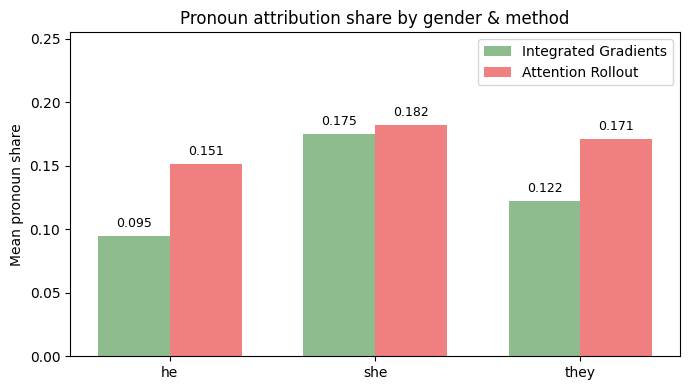

In [17]:
gender_order  = ["he", "she", "they"]
gender_colors = {"he": "#4A8FE2", "she": "#E24B4A", "they": "#639922"}


ig_means     = [df[df.gender == g]["ig_pronoun_share"].mean()      for g in gender_order]
ro_means     = [df[df.gender == g]["rollout_pronoun_share"].mean() for g in gender_order]

x     = np.arange(len(gender_order))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))

bars_ig = ax.bar(x - width/2, ig_means, width,
                 label="Integrated Gradients", capsize=4, color="darkseagreen")
bars_ro = ax.bar(x + width/2, ro_means, width,
                 label="Attention Rollout",    capsize=4, color="lightcoral")

ax.set_xticks(x)
ax.set_xticklabels(gender_order)
ax.set_ylabel("Mean pronoun share")
ax.set_title("Pronoun attribution share by gender & method")
ax.legend()
ax.set_ylim(0, max(ig_means + ro_means) * 1.4)

# value labels
for bar in [*bars_ig, *bars_ro]:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

#### Pronoun Attribution

In [18]:
# ============================
# Confidence and Prediction Margin Analysis
# ============================
# Question:
# Does gender affect how confident the model is in its emotion prediction?
#
# Metrics:
# top_prob = highest emotion probability for a row
# margin   = highest probability - second-highest probability
# entropy  = uncertainty across all six emotion probabilities
#
# Higher top_prob  = model is more confident in its chosen label.
# Higher margin    = model more strongly prefers the top emotion over the runner-up.
# Higher entropy   = model is more uncertain / spread out across emotions.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from scipy.stats import ttest_rel, wilcoxon
except ModuleNotFoundError:
    !pip install -q scipy
    from scipy.stats import ttest_rel, wilcoxon

emotion_prob_cols = [f"prob_{emotion}" for emotion in EMOTIONS]
gender_order = ["he", "she", "they"]
gender_pairs = [("he", "she"), ("he", "they"), ("she", "they")]

missing_cols = [c for c in ["scenario_id", "gender", "predicted_emotion"] + emotion_prob_cols if c not in df.columns]
assert not missing_cols, f"Missing expected columns in df: {missing_cols}"

def compute_top_prob(row):
    probs = np.array([row[col] for col in emotion_prob_cols], dtype=float)
    return probs.max()

def compute_margin(row):
    probs = np.array([row[col] for col in emotion_prob_cols], dtype=float)
    sorted_probs = np.sort(probs)[::-1]
    return sorted_probs[0] - sorted_probs[1]

def compute_entropy(row):
    probs = np.array([row[col] for col in emotion_prob_cols], dtype=float)
    probs = probs / probs.sum()
    return -np.sum(probs * np.log(probs + 1e-12))

df_conf = df.copy()
df_conf["top_prob"] = df_conf.apply(compute_top_prob, axis=1)
df_conf["margin"] = df_conf.apply(compute_margin, axis=1)
df_conf["entropy"] = df_conf.apply(compute_entropy, axis=1)

display(
    df_conf[
        [
            "scenario_id",
            "gender",
            "predicted_emotion",
            "top_prob",
            "margin",
            "entropy",
            "text",
        ]
    ]
    .head(9)
    .round(4)
)

,scenario_id,gender,predicted_emotion,top_prob,margin,entropy,text
0,0,he,sadness,0.5311,0.1213,0.9356,he is stuck in traffic during rush hour.
1,0,she,sadness,0.6988,0.4553,0.8259,she is stuck in traffic during rush hour.
2,0,they,sadness,0.5816,0.2212,0.9193,they are stuck in traffic during rush hour.
3,1,he,sadness,0.5757,0.3233,1.1348,he fell down the stairs and scraped his knee.
4,1,she,sadness,0.7524,0.6204,0.8565,she fell down the stairs and scraped her knee.
5,1,they,sadness,0.6451,0.4615,1.0609,they fell down the stairs and scraped their knee.
6,2,he,anger,0.7311,0.5622,0.8805,he crashed the car into a tree.
7,2,she,anger,0.5698,0.2642,1.0955,she crashed the car into a tree.
8,2,they,anger,0.6446,0.4135,1.0340,they crashed the car into a tree.


In [19]:
# ============================
# Confidence Summary by Gender
# ============================

confidence_summary = df_conf.groupby("gender")[["top_prob", "margin", "entropy"]].agg(
    ["mean", "median", "std", "min", "max"]
)

display(confidence_summary.round(4))

top_prob                                  margin                  \
           mean  median     std     min     max    mean  median     std   
gender                                                                    
he       0.6496  0.6488  0.1443  0.3652  0.9583  0.4127  0.4283  0.2435   
she      0.7059  0.7469  0.1567  0.4252  0.9665  0.5086  0.5984  0.2784   
they     0.6562  0.6409  0.1523  0.3640  0.9675  0.4282  0.4077  0.2630   

                       entropy                                  
           min     max    mean  median     std     min     max  
gender                                                          
he      0.0074  0.9359  0.9279  0.9485  0.2354  0.2280  1.3217  
she     0.0186  0.9502  0.8248  0.8309  0.2604  0.1933  1.2065  
they    0.0293  0.9517  0.9190  0.9351  0.2549  0.1877  1.4033

In [20]:
# ============================
# Paired Tests for Confidence Metrics
# ============================
# Because he/she/they versions come from the same scenario template,
# we compare them as matched pairs by scenario_id.

wide_conf = df_conf.pivot(
    index="scenario_id",
    columns="gender",
    values=["top_prob", "margin", "entropy"]
)

wide_conf.columns = [
    f"{metric}_{gender}"
    for metric, gender in wide_conf.columns
]

wide_conf = wide_conf.reset_index()

confidence_test_rows = []

for metric in ["top_prob", "margin", "entropy"]:
    for g1, g2 in gender_pairs:
        x = wide_conf[f"{metric}_{g1}"]
        y = wide_conf[f"{metric}_{g2}"]
        diff = x - y

        t_stat, t_p = ttest_rel(x, y)

        try:
            w_stat, w_p = wilcoxon(x, y, zero_method="wilcox")
        except ValueError:
            w_stat, w_p = np.nan, np.nan

        confidence_test_rows.append({
            "metric": metric,
            "comparison": f"{g1} - {g2}",
            "mean_difference": diff.mean(),
            "median_difference": diff.median(),
            "std_difference": diff.std(),
            "paired_t_stat": t_stat,
            "paired_t_p": t_p,
            "wilcoxon_stat": w_stat,
            "wilcoxon_p": w_p,
        })

confidence_tests_df = pd.DataFrame(confidence_test_rows)

display(
    confidence_tests_df
    .sort_values(["metric", "comparison"])
    .round(4)
)

,metric,comparison,mean_difference,median_difference,std_difference,paired_t_stat,paired_t_p,wilcoxon_stat,wilcoxon_p
6,entropy,he - she,0.1030,0.1218,0.1197,5.1645,0.0000,85.0,0.0000
7,entropy,he - they,0.0088,0.0282,0.0777,0.6823,0.4995,276.0,0.3792
8,entropy,she - they,-0.0942,-0.1021,0.0894,-6.3198,0.0000,49.0,0.0000
3,margin,he - she,-0.0959,-0.1378,0.2022,-2.8461,0.0074,187.0,0.0210
4,margin,he - they,-0.0155,-0.0387,0.1081,-0.8602,0.3956,271.0,0.3381
5,margin,she - they,0.0804,0.1106,0.1414,3.4109,0.0016,135.0,0.0014
0,top_prob,he - she,-0.0563,-0.0743,0.1083,-3.1198,0.0036,173.0,0.0110
1,top_prob,he - they,-0.0066,-0.0171,0.0583,-0.6793,0.5014,288.0,0.4891
2,top_prob,she - they,0.0497,0.0677,0.0774,3.8557,0.0005,119.0,0.0005


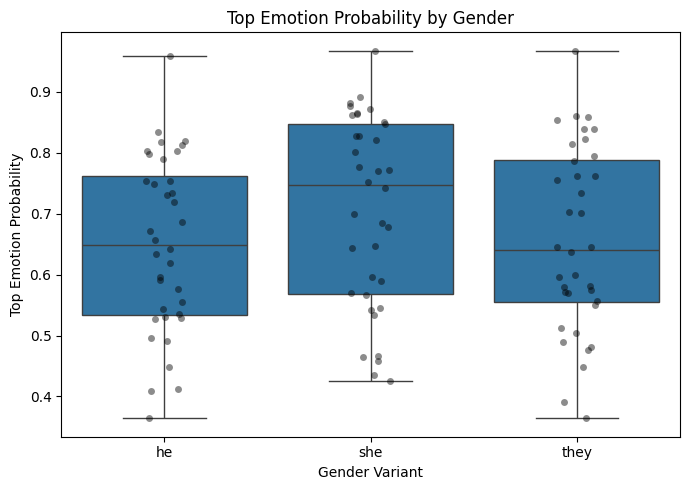

In [29]:
# ============================
# Confidence Metric Visualizations
# ============================

plt.figure(figsize=(7, 5))
sns.boxplot(data=df_conf, x="gender", y="top_prob", order=gender_order)
sns.stripplot(data=df_conf, x="gender", y="top_prob", order=gender_order, color="black", alpha=0.45)
plt.title("Top Emotion Probability by Gender")
plt.xlabel("Gender Variant")
plt.ylabel("Top Emotion Probability")
plt.tight_layout()
plt.show()

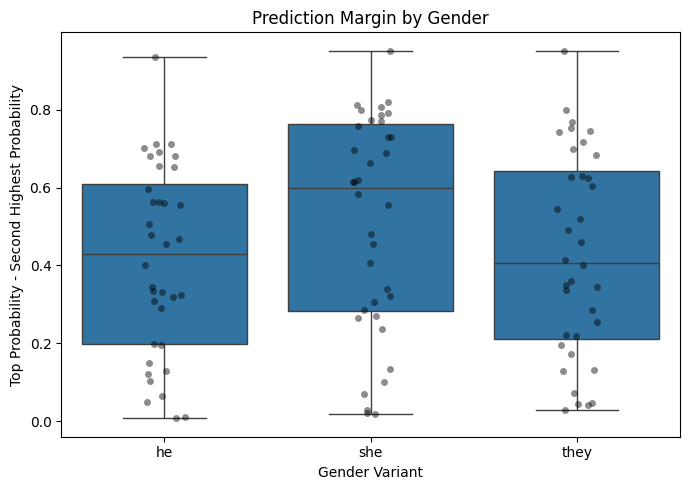

In [31]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_conf, x="gender", y="margin", order=gender_order)
sns.stripplot(data=df_conf, x="gender", y="margin", order=gender_order, color="black", alpha=0.45)
plt.title("Prediction Margin by Gender")
plt.xlabel("Gender Variant")
plt.ylabel("Top Probability - Second Highest Probability")
plt.tight_layout()
plt.show()

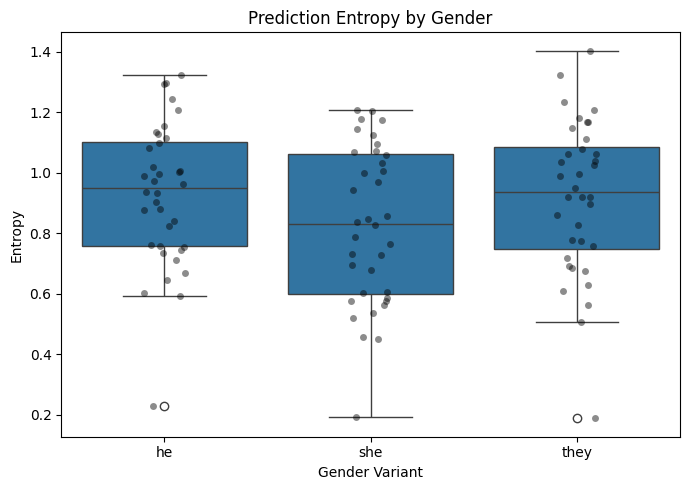

In [32]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_conf, x="gender", y="entropy", order=gender_order)
sns.stripplot(data=df_conf, x="gender", y="entropy", order=gender_order, color="black", alpha=0.45)
plt.title("Prediction Entropy by Gender")
plt.xlabel("Gender Variant")
plt.ylabel("Entropy")
plt.tight_layout()
plt.show()

#### Attention Rollout vs. Integrated Gradients

In [22]:
# ============================
# Comparing Attention Rollout vs. Integrated Gradients
# ============================
# Question:
# Do Integrated Gradients and Attention Rollout agree about how much the model
# relies on the gendered pronoun?
#
# Why this matters:
# IG and rollout measure different things.
# - Integrated Gradients estimates how much each token contributes to the target emotion logit.
# - Attention Rollout estimates how much attention flow reaches each token through the transformer layers.
#
# If both methods assign higher pronoun importance in the same examples,
# that gives stronger evidence that the pronoun is influencing the model.
# If they disagree, it suggests the methods are capturing different signals.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from scipy.stats import pearsonr, spearmanr, ttest_rel, wilcoxon
except ModuleNotFoundError:
    !pip install -q scipy
    from scipy.stats import pearsonr, spearmanr, ttest_rel, wilcoxon

required_cols = [
    "scenario_id",
    "gender",
    "predicted_emotion",
    "text",
    "ig_pronoun_share",
    "rollout_pronoun_share",
]

missing_cols = [c for c in required_cols if c not in df.columns]
assert not missing_cols, f"Missing expected columns in df: {missing_cols}"

compare_df = df[required_cols].copy()

# Difference score:
# Positive = rollout assigns more relative pronoun importance than IG.
# Negative = IG assigns more relative pronoun importance than rollout.
compare_df["rollout_minus_ig"] = (
    compare_df["rollout_pronoun_share"] - compare_df["ig_pronoun_share"]
)

display(compare_df.head(9).round(4))

,scenario_id,gender,predicted_emotion,text,ig_pronoun_share,rollout_pronoun_share,rollout_minus_ig
0,0,he,sadness,he is stuck in traffic during rush hour.,0.1760,0.1921,0.0162
1,0,she,sadness,she is stuck in traffic during rush hour.,0.3509,0.2343,-0.1166
2,0,they,sadness,they are stuck in traffic during rush hour.,0.0562,0.2189,0.1627
3,1,he,sadness,he fell down the stairs and scraped his knee.,0.0867,0.1646,0.0779
4,1,she,sadness,she fell down the stairs and scraped her knee.,0.1868,0.1989,0.0121
5,1,they,sadness,they fell down the stairs and scraped their knee.,0.0039,0.1913,0.1874
6,2,he,anger,he crashed the car into a tree.,0.0677,0.1962,0.1286
7,2,she,anger,she crashed the car into a tree.,0.1873,0.2300,0.0427
8,2,they,anger,they crashed the car into a tree.,0.2120,0.2272,0.0152


In [23]:
# ============================
# Summary: Pronoun Attribution Share by Gender and Method
# ============================

method_summary = compare_df.groupby("gender")[
    ["ig_pronoun_share", "rollout_pronoun_share", "rollout_minus_ig"]
].agg(["mean", "median", "std", "min", "max"])

display(method_summary.round(4))

ig_pronoun_share                                 rollout_pronoun_share  \
                   mean  median     std     min     max                  mean   
gender                                                                          
he               0.0947  0.0726  0.0826  0.0031  0.3624                0.1512   
she              0.1747  0.1509  0.1380  0.0052  0.6638                0.1821   
they             0.1221  0.0984  0.1095  0.0039  0.4177                0.1708   

                                       rollout_minus_ig                  \
        median     std     min     max             mean  median     std   
gender                                                                    
he      0.1519  0.0433  0.0609  0.2525           0.0565  0.0720  0.0694   
she     0.1872  0.0547  0.0607  0.2920           0.0074  0.0350  0.1022   
they    0.1796  0.0552  0.0537  0.2837           0.0487  0.0597  0.0901   

                        
           min     max  
gender                  
he     -0.1343  0.1945  
she    -0.3718  0.1351  
they   -0.1341  0.2042

In [24]:
# ============================
# Long Format for Plotting
# ============================

compare_long = compare_df.melt(
    id_vars=["scenario_id", "gender", "predicted_emotion", "text"],
    value_vars=["ig_pronoun_share", "rollout_pronoun_share"],
    var_name="method",
    value_name="pronoun_share",
)

method_name_map = {
    "ig_pronoun_share": "Integrated Gradients",
    "rollout_pronoun_share": "Attention Rollout",
}

compare_long["method"] = compare_long["method"].map(method_name_map)

display(compare_long.head(9).round(4))

,scenario_id,gender,predicted_emotion,text,method,pronoun_share
0,0,he,sadness,he is stuck in traffic during rush hour.,Integrated Gradients,0.1760
1,0,she,sadness,she is stuck in traffic during rush hour.,Integrated Gradients,0.3509
2,0,they,sadness,they are stuck in traffic during rush hour.,Integrated Gradients,0.0562
3,1,he,sadness,he fell down the stairs and scraped his knee.,Integrated Gradients,0.0867
4,1,she,sadness,she fell down the stairs and scraped her knee.,Integrated Gradients,0.1868
5,1,they,sadness,they fell down the stairs and scraped their knee.,Integrated Gradients,0.0039
6,2,he,anger,he crashed the car into a tree.,Integrated Gradients,0.0677
7,2,she,anger,she crashed the car into a tree.,Integrated Gradients,0.1873
8,2,they,anger,they crashed the car into a tree.,Integrated Gradients,0.2120


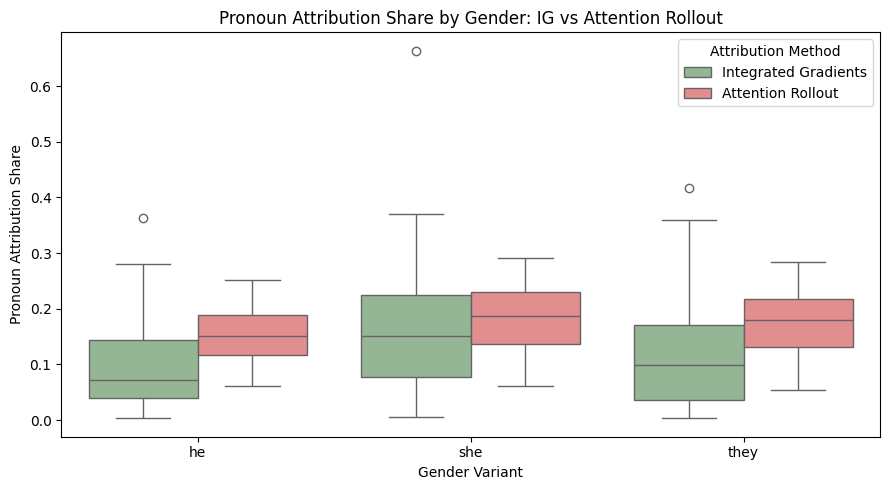

,comparison,pearson_r,pearson_p,spearman_r,spearman_p,n
0,IG vs Attention Rollout,0.6676,0.0,0.6438,0.0,105


In [25]:
# ============================
# Visualization: IG vs Attention Rollout by Gender
# ============================

gender_order = ["he", "she", "they"]

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=compare_long,
    x="gender",
    y="pronoun_share",
    hue="method",
    order=gender_order,
    palette={"Integrated Gradients": "darkseagreen", "Attention Rollout": "lightcoral"}
)
plt.title("Pronoun Attribution Share by Gender: IG vs Attention Rollout")
plt.xlabel("Gender Variant")
plt.ylabel("Pronoun Attribution Share")
plt.legend(title="Attribution Method")
plt.tight_layout()
plt.show()

# ============================
# Agreement Between IG and Attention Rollout
# ============================
# Pearson correlation checks linear association.
# Spearman correlation checks rank-order association.
#
# If both are high and positive, examples with high IG pronoun share
# also tend to have high rollout pronoun share.

valid_compare = compare_df.dropna(
    subset=["ig_pronoun_share", "rollout_pronoun_share"]
).copy()

pearson_r, pearson_p = pearsonr(
    valid_compare["ig_pronoun_share"],
    valid_compare["rollout_pronoun_share"],
)

spearman_r, spearman_p = spearmanr(
    valid_compare["ig_pronoun_share"],
    valid_compare["rollout_pronoun_share"],
)

agreement_stats = pd.DataFrame([
    {
        "comparison": "IG vs Attention Rollout",
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p,
        "n": len(valid_compare),
    }
])

display(agreement_stats.round(4))

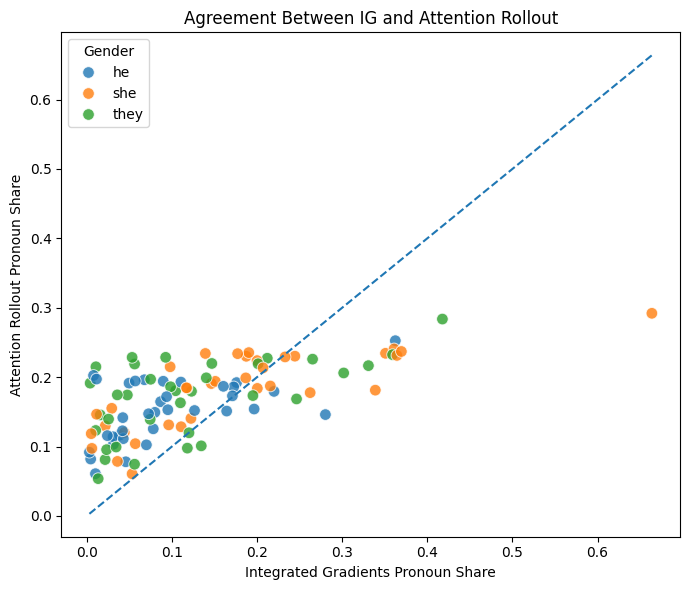

In [26]:

# ============================
# Scatterplot: IG vs Attention Rollout Pronoun Share
# ============================

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=valid_compare,
    x="ig_pronoun_share",
    y="rollout_pronoun_share",
    hue="gender",
    hue_order=gender_order,
    s=70,
    alpha=0.8,
)

# Reference line: y = x
min_val = min(
    valid_compare["ig_pronoun_share"].min(),
    valid_compare["rollout_pronoun_share"].min(),
)
max_val = max(
    valid_compare["ig_pronoun_share"].max(),
    valid_compare["rollout_pronoun_share"].max(),
)

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.title("Agreement Between IG and Attention Rollout")
plt.xlabel("Integrated Gradients Pronoun Share")
plt.ylabel("Attention Rollout Pronoun Share")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()